# IND320 Project, assignment 1

By: Ole Andreas Grøtting\
Github: IND320 - OLEGRO99\
Streamlit: 

### Imports

In [1]:
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%matplotlib inline

### load the dataset

In [3]:
reservoirs = pd.read_csv("data/reservoirs.csv", sep = ",")
reservoirs.head()
#we can see that some of the dates in "neste publiseringsdato" are set to 1 of january year 1.

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## data cleaning

In [4]:
reservoirs = reservoirs.rename(columns={"dato_Id": "Date", 
                                        "omrType": "Region",
                                        "omrnr": "Region_Number",
                                        "iso_aar": "iso_year", 
                                        "iso_uke": "iso_week",
                                        "fyllingsgrad": "filling_level",
                                        "kapasitet_TWh": "Capacity(TWh)", 
                                        "fylling_TWh": "Filled (TWh)",
                                        "neste_Publiseringsdato": "Next_Publication_Date",
                                        "fyllingsgrad_forrige_uke": "filling_level_previous_week",
                                        "endring_fyllingsgrad": "change_filling_level"
})
reservoirs.head()

,Date,Region,Region_Number,iso_year,iso_week,filling_level,Capacity(TWh),Filled (TWh),Next_Publication_Date,filling_level_previous_week,change_filling_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [ ]:
reservoirs["Date"] = pd.to_datetime(reservoirs["Date"], errors='coerce')
reservoirs['Next_Publication_Date'] = pd.to_datetime(reservoirs['Next_Publication_Date'], errors='coerce')
reservoirs.loc[
    reservoirs["Next_Publication_Date"].dt.year == 1,
    "Next_Publication_Date"
] = pd.NaT  # Replace year 1 with NaT
reservoirs = reservoirs.dropna(subset=["Next_Publication_Date"])
# removing the rows with the year 1 in "neste publiseringsdato" and dropping the rows with NaT values in "neste publiseringsdato"
reservoirs.head()

,Date,Region,Region_Number,iso_year,iso_week,filling_level,Capacity(TWh),Filled (TWh),Next_Publication_Date,filling_level_previous_week,change_filling_level
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25 13:00:00,0.997406,-0.023046
9,2023-08-13,EL,5,2023,32,0.836849,17.390587,14.553301,2023-08-23 13:00:00,0.776765,0.060084
12,2021-04-18,EL,5,2021,15,0.246682,17.390587,4.289936,2021-04-28 13:00:00,0.276825,-0.030144
13,2019-06-02,EL,1,2019,22,0.659981,6.003264,3.962040,2019-06-12 13:00:00,0.625398,0.034583
15,2019-10-27,EL,1,2019,43,0.896057,6.003264,5.379270,2019-11-06 13:00:00,0.882742,0.013315


In [5]:
reservoirs.info()
reservoirs.describe()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         14877 non-null  str    
 1   Region                       14877 non-null  str    
 2   Region_Number                14877 non-null  int64  
 3   iso_year                     14877 non-null  int64  
 4   iso_week                     14877 non-null  int64  
 5   filling_level                14877 non-null  float64
 6   Capacity(TWh)                14877 non-null  float64
 7   Filled (TWh)                 14877 non-null  float64
 8   Next_Publication_Date        14877 non-null  str    
 9   filling_level_previous_week  14877 non-null  float64
 10  change_filling_level         14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB


,Region_Number,iso_year,iso_week,filling_level,Capacity(TWh),Filled (TWh),filling_level_previous_week,change_filling_level
count,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0.618890,-0.000038
std,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,0.214843,0.031385
min,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0.802133,0.016277
max,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,1.020037,0.336623


## plotting the data

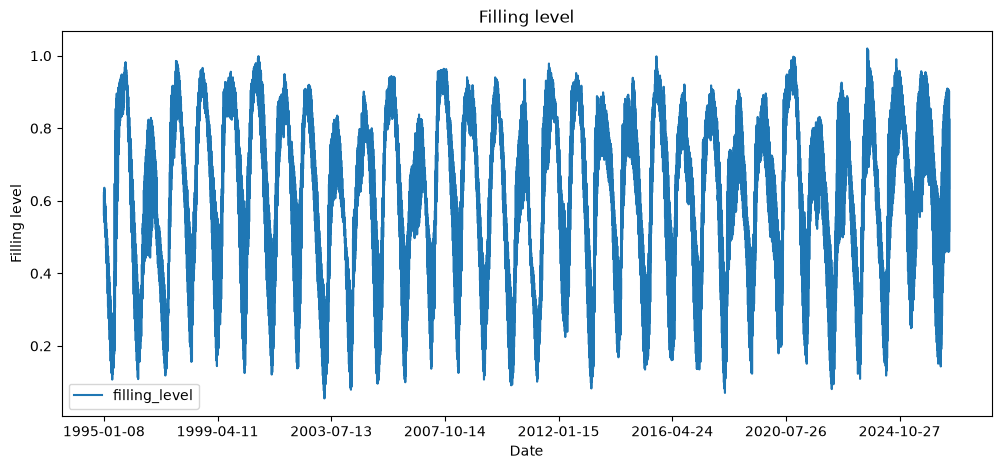

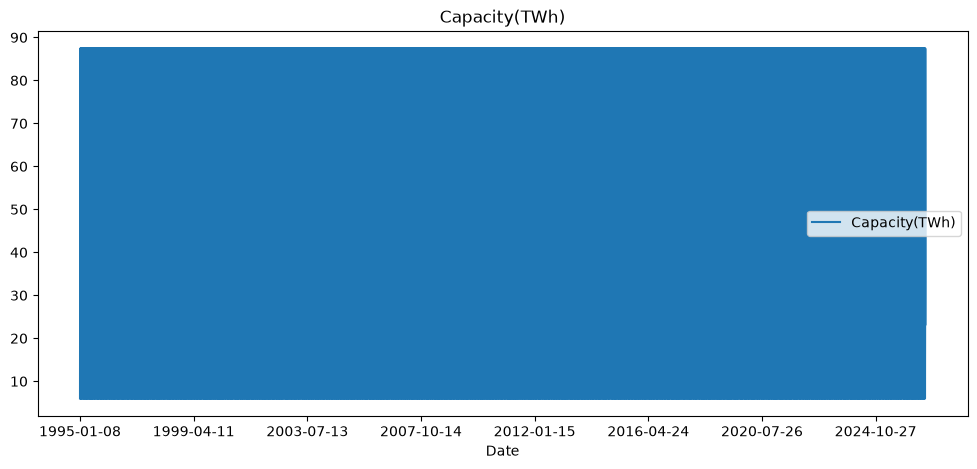

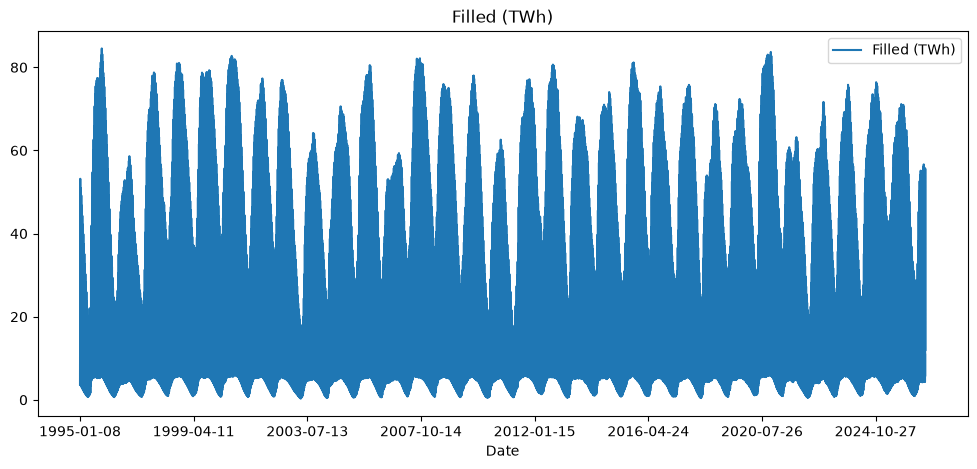

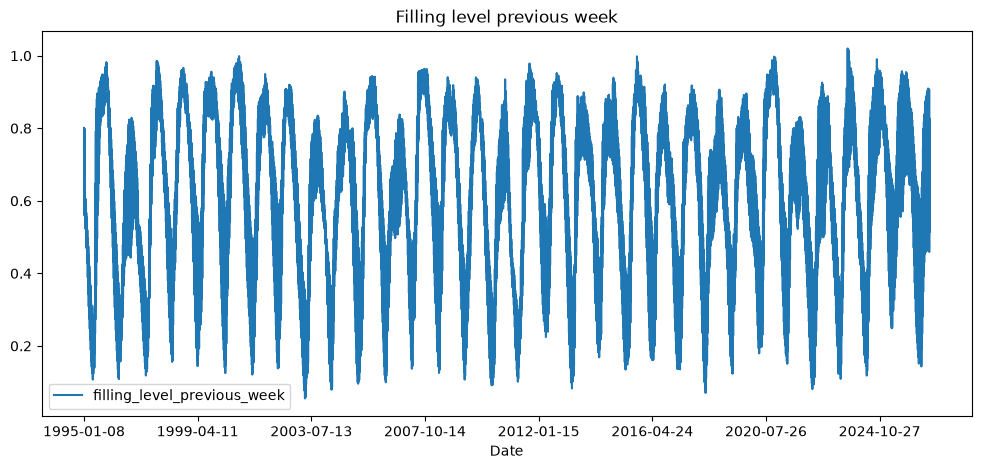

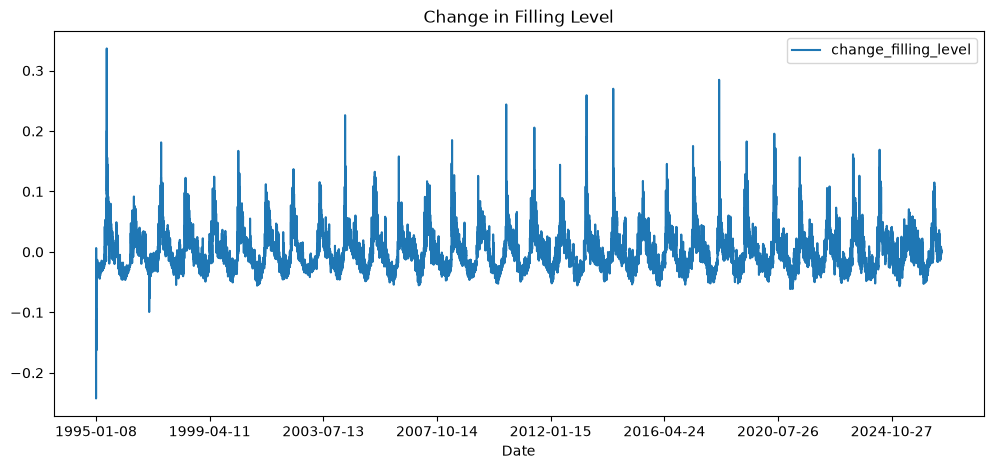

In [6]:
#Plotting numerical columns
reservoirs = reservoirs.sort_values("Date")

reservoirs.plot(
    x="Date",
    y="filling_level",
    figsize=(12, 5)
)

plt.title("Filling level")
plt.xlabel("Date")
plt.ylabel("Filling level")
plt.show()

reservoirs = reservoirs.sort_values("Date")

reservoirs.plot(
    x="Date",
    y="Capacity(TWh)",
    figsize=(12, 5)
)

plt.title("Capacity(TWh)")
plt.show()

reservoirs = reservoirs.sort_values("Date")

reservoirs.plot(
    x="Date",
    y="Filled (TWh)",
    figsize=(12, 5)
)

plt.title("Filled (TWh)")
plt.show()

reservoirs = reservoirs.sort_values("Date")

reservoirs.plot(
    x="Date",
    y="filling_level_previous_week",
    figsize=(12, 5)
)

plt.title("Filling level previous week")
plt.show()

reservoirs = reservoirs.sort_values("Date")

reservoirs.plot(
    x="Date",
    y="change_filling_level",
    figsize=(12, 5)
)

plt.title("Change in Filling Level")
plt.show()

Capasity is a box beacause the capasity is constant for every reservoir.
 

In [ ]:
#plotting categorical columns


### plotting all colums in the same plot

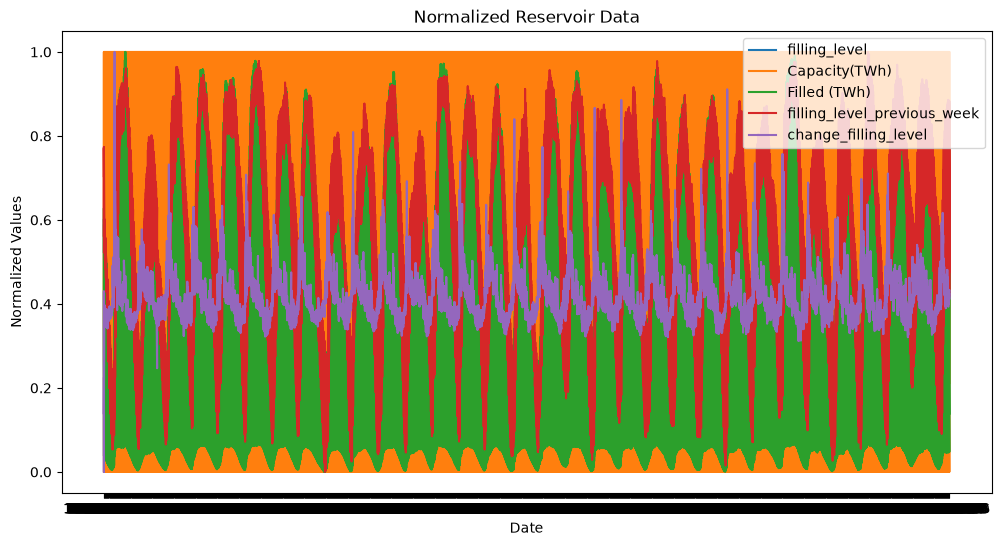

In [7]:
#min max normalize
resorvoirs_norm = reservoirs.copy()
numerical_columns = ["filling_level", "Capacity(TWh)", "Filled (TWh)", "filling_level_previous_week", "change_filling_level"]
for col in numerical_columns:
    mn, mx = resorvoirs_norm[col].min(), resorvoirs_norm[col].max()
    resorvoirs_norm[col] = (resorvoirs_norm[col] - mn) / (mx - mn)

#plotting all together
plt.figure(figsize=(12, 6))
for col in numerical_columns:
    plt.plot(resorvoirs_norm["Date"], resorvoirs_norm[col], label=col)
plt.title("Normalized Reservoir Data")
plt.xlabel("Date")
plt.ylabel("Normalized Values")
plt.legend(loc='upper right')
plt.show()

In [ ]:
#making a prossessed csv file for the data to be used in the streamlit app
reservoirs.to_csv("data/reservoirs_processed.csv", index=False)

# log\
I first started with creating a streamlit account and connecting it to my github account. I got some problems beacuse i made 2 seperate repositorys, but i used AI to fix it. From the data set i saw some of the Next_Publication_Date dates where set to 1 january year 1 and i removed these dates. I then did some data cleaning and plotted the numerical as line plot and categorical as box plots. Then i tried to plot all of the numerical variables together using min/max scaling but i encountered some problems during and the plot was wrong. I went to the teaching assisant and got it fixed with his help and a bit off help from AI.